# 미니프로젝트: 회귀 및 분류 모델링 (Vibe Coding)

#### <목표>
Day 2에서 배운 **다중선형회귀, Ridge·Lasso, 로지스틱 회귀, 의사결정나무**를 새로운 제조 데이터셋에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>

**1) 회귀용 — Mining Process Flotation Plant (광물 선광 공정 데이터)**
- 철광석을 선광(flotation)하는 공정에서 1시간 간격으로 수집된 실제 산업 데이터 (2017.03~2017.09)
- 공정 변수로 최종 정광의 불순물(실리카) 비율을 예측

| 변수명 | 설명 |
|:---:|:---|
| date | 측정 일시 |
| % Iron Feed, % Silica Feed | 투입 원광의 철/실리카 품위 |
| Starch Flow, Amina Flow | 전분/아민 투입량 (시약) |
| Ore Pulp Flow, pH, Density | 광액 유량/산도/밀도 |
| Flotation Column 01~07 Air Flow | 플로테이션 컬럼별 공기 유량 |
| Flotation Column 01~07 Level | 플로테이션 컬럼별 액위 |
| % Iron Concentrate | 최종 정광의 철 비율 (실험실 측정) |
| **% Silica Concentrate** | **최종 정광의 실리카(불순물) 비율 — 회귀 타겟** |

**2) 분류용 — Steel Plates Faults (철강 표면 결함 검사 데이터)**
- 철강판 표면을 촬영해 측정한 결함의 위치/크기/광도 등으로 결함 유형을 분류하는 실제 품질검사 데이터

| 변수명 | 설명 |
|:---:|:---|
| X/Y_Minimum, X/Y_Maximum | 결함의 위치 범위 |
| Pixels_Areas, X/Y_Perimeter | 결함의 면적·둘레 |
| Sum/Minimum/Maximum_of_Luminosity | 결함 부위의 광도 |
| Length_of_Conveyer, Steel_Plate_Thickness | 설비/소재 정보 |
| TypeOfSteel_A300, TypeOfSteel_A400 | 철강 타입 |
| Edges_Index, Square_Index, Luminosity_Index 등 | 결함 형태 특징 지수 |
| Pastry, Z_Scratch, K_Scatch, Stains, Dirtiness, Bumps, Other_Faults | 결함 유형 |
| **K_Scatch** | **긴 스크래치성 결함 여부 — 분류 타겟** |

#### <실습 태스크>
| 태스크 | 데이터 파일 | 타겟 변수 | 사용 모델 |
|:---:|:---:|:---:|:---|
| 회귀 | `dataset/day2_miniproject_reg.csv` | `% Silica Concentrate` | 다중선형회귀, Ridge, Lasso, 의사결정나무 회귀 |
| 분류 | `dataset/day2_miniproject_cls.csv` | `K_Scatch` (재구성 필요) | 로지스틱 회귀, 의사결정나무 분류 |

#### <진행 순서>
**Part A(회귀)** 를 데이터 불러오기 → 탐색 → 전처리 → 모델링 → 예측 → 고도화 → 결과 해석까지 **끝까지 완료한 뒤**, **Part B(분류)** 를 동일한 흐름으로 진행합니다.

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

**[과제]** 써니는 이번에는 제조 공정 데이터를 가지고 회귀와 분류를 모두 다뤄야 합니다. 분석에 필요한 라이브러리를 AI와 상의해서 불러오세요.

In [1]:
# 기본
import os
import warnings
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 분할 / 튜닝
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# 전처리
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 회귀 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# 분류 모델
from sklearn.linear_model import LogisticRegression

# 의사결정나무
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn import tree

# 회귀 성능 지표
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

# 분류 성능 지표
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)

In [14]:
#한글폰트
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "AppleGothic"   # macOS 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False     # 마이너스 기호 깨짐 방지

---
# Part A. 회귀 태스크 — Mining Process Flotation Plant

## A-0) 데이터 불러오기

**[과제]** 써니는 `dataset/day2_miniproject_reg.csv` 파일을 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [3]:
df_reg = pd.read_csv('/Users/user/Desktop/cursor 연습/9일차/dataset/day2_miniproject_reg.csv')

In [4]:
df_reg.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,3/29/2017 12:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,3/29/2017 13:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,3/29/2017 14:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,3/29/2017 15:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,3/29/2017 16:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50


---
## A-1) 데이터 탐색 (EDA)

### A-1-1) Value 기반 탐색

**[과제]** 써니는 데이터에 대한 이해 없이 모델링을 진행하는 것이 불안합니다. AI와 함께 데이터의 어떤 특성을 먼저 확인해야 하는지 논의하고, 실제로 데이터를 탐색하여 분석에 필요한 인사이트를 도출해 보세요.

In [ ]:
target = "% Silica Concentrate"

# 1. 크기 / 컬럼 / 자료형
print("=== 데이터 크기 ===")
print(df_reg.shape)

print("\n=== 변수명 ===")
print(df_reg.columns.tolist())

print("\n=== 데이터 타입 ===")
print(df_reg.dtypes)

print("\n=== 기본 통계량 ===")
display(df_reg.describe())

print(df_reg.info())

=== 데이터 크기 ===
(3948, 24)

=== 변수명 ===
['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Iron Concentrate', '% Silica Concentrate']

=== 데이터 타입 ===
date                             object
% Iron Feed                     float64
% Silica Feed                   float64
Starch Flow                     float64
Amina Flow                      float64
Ore Pulp Flow                   float64
Ore Pulp pH                     float64
Ore Pulp Density                float64
Flotation Column 01 Air Flow  

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,...,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000
mean,56.220301,14.767789,2847.012956,488.720690,397.471417,9.769643,1.679042,281.287417,278.182019,282.253076,...,292.293595,520.425277,523.195899,532.182319,418.095661,422.776652,426.996977,418.128753,65.027176,2.322261
std,5.231150,6.887711,948.913479,83.769854,8.491449,0.378012,0.063417,29.361843,29.490104,28.244196,...,26.527575,123.756672,116.664614,140.549112,76.142141,74.612107,74.714161,71.636366,1.109367,1.120117
min,42.740000,1.310000,54.595483,242.927477,376.837604,8.753389,1.519926,175.885579,178.188430,177.202665,...,199.728122,181.925623,224.909663,135.214506,165.725058,214.735894,203.702926,185.061388,62.050000,0.600000
25%,52.610000,8.812500,2146.232398,436.428747,398.774394,9.542790,1.649868,250.109688,250.119040,250.109164,...,299.031694,409.067986,449.187215,402.250428,351.264361,350.829644,353.171861,350.734692,64.350000,1.440000
50%,55.940000,14.200000,2880.359057,502.685958,399.835435,9.796511,1.694900,299.850578,299.596767,299.893233,...,299.876333,499.582128,499.840739,499.584794,400.834364,400.626158,402.707483,400.495361,65.190000,2.000000
75%,59.720000,20.140000,3514.789671,550.144572,400.592916,10.033416,1.719869,299.955660,299.991808,299.948658,...,300.129489,599.849921,599.424594,600.303602,494.603949,497.296990,489.623260,454.574938,65.830000,2.992500
max,65.780000,33.400000,6270.158798,736.982378,418.070232,10.807370,1.818191,312.295415,309.887767,302.783000,...,351.268656,859.025062,827.775874,884.840698,675.631942,674.068176,698.505832,655.501603,68.010000,5.530000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3948 entries, 0 to 3947
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          3948 non-null   object 
 1   % Iron Feed                   3948 non-null   float64
 2   % Silica Feed                 3948 non-null   float64
 3   Starch Flow                   3948 non-null   float64
 4   Amina Flow                    3948 non-null   float64
 5   Ore Pulp Flow                 3948 non-null   float64
 6   Ore Pulp pH                   3948 non-null   float64
 7   Ore Pulp Density              3948 non-null   float64
 8   Flotation Column 01 Air Flow  3948 non-null   float64
 9   Flotation Column 02 Air Flow  3948 non-null   float64
 10  Flotation Column 03 Air Flow  3948 non-null   float64
 11  Flotation Column 04 Air Flow  3948 non-null   float64
 12  Flotation Column 05 Air Flow  3948 non-null   float64
 13  Flo

In [11]:
print("=== 결측치 개수 ===")
print(df_reg.isnull().sum())

print("\n=== 결측치 비율(%) ===")
print((df_reg.isnull().mean() * 100).round(2))

print("\n=== 중복 행 ===")
print(df_reg.duplicated().sum())

print("\n=== date 고유값 수 ===")
print(df_reg["date"].nunique())

=== 결측치 개수 ===
date                            0
% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64

=== 결측치 비율(%) ===
date                            0.0
% Iron Feed                     0.0
% Silica Feed                   0.0
Starch Flow                  

### A-1-2) Graph 기반 탐색

**[과제]** 써니는 데이터를 살펴보던 중 변수들이 시간에 따라 수집된 값이라는 사실을 확인했습니다. 이에 따라 시간의 흐름에 따라 각 변수의 값이 어떻게 변화하는지 궁금해졌습니다. AI와 함께 시계열 데이터에 적합한 시각화 방법을 논의하고 변수별 변화를 직접 시각화하여 데이터에서 발견한 특징과 인사이트를 정리해 보세요.

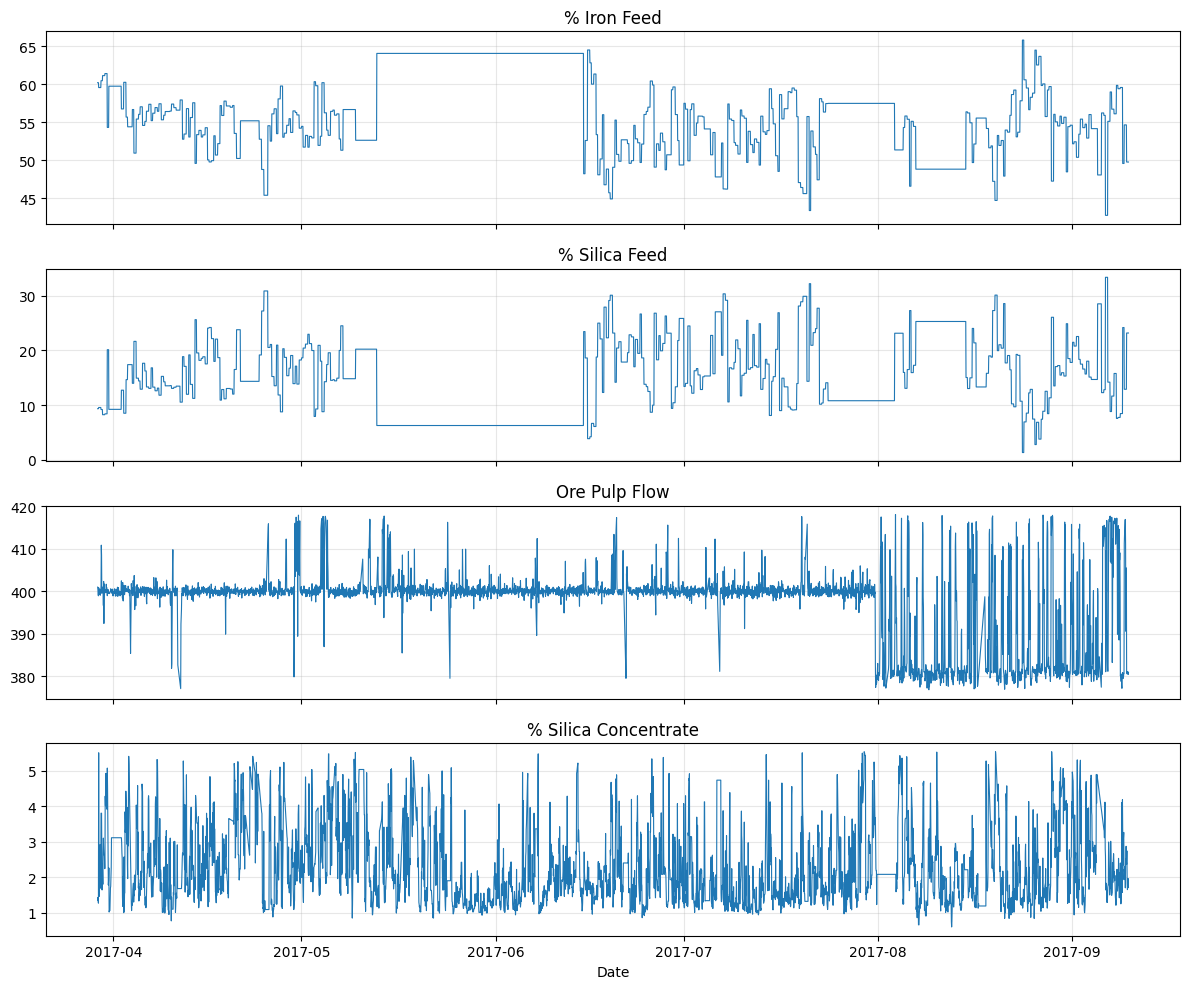

In [12]:
df_ts = df_reg.copy()
df_ts["date"] = pd.to_datetime(df_ts["date"])
df_ts = df_ts.sort_values("date")

cols = ["% Iron Feed", "% Silica Feed", "Ore Pulp Flow", "% Silica Concentrate"]

fig, axes = plt.subplots(len(cols), 1, figsize=(12, 2.5 * len(cols)), sharex=True)
for ax, col in zip(axes, cols):
    ax.plot(df_ts["date"], df_ts[col], linewidth=0.8)
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.xlabel("Date")
plt.tight_layout()
plt.show()

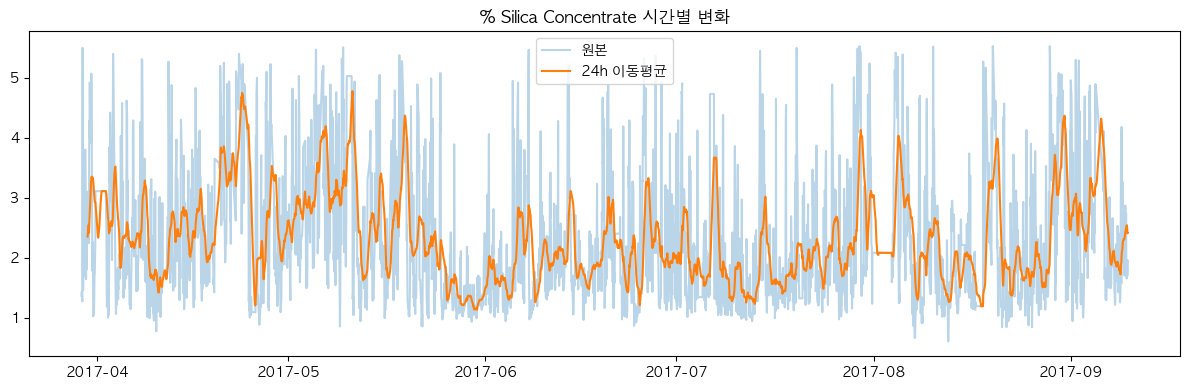

In [15]:
target = "% Silica Concentrate"

plt.figure(figsize=(12, 4))
plt.plot(df_ts["date"], df_ts[target], alpha=0.3, label="원본")
plt.plot(df_ts["date"], df_ts[target].rolling(24).mean(), label="24h 이동평균")
plt.legend()
plt.title(f"{target} 시간별 변화")
plt.tight_layout()
plt.show()

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. 전체 변수 간 관계를 효율적으로 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

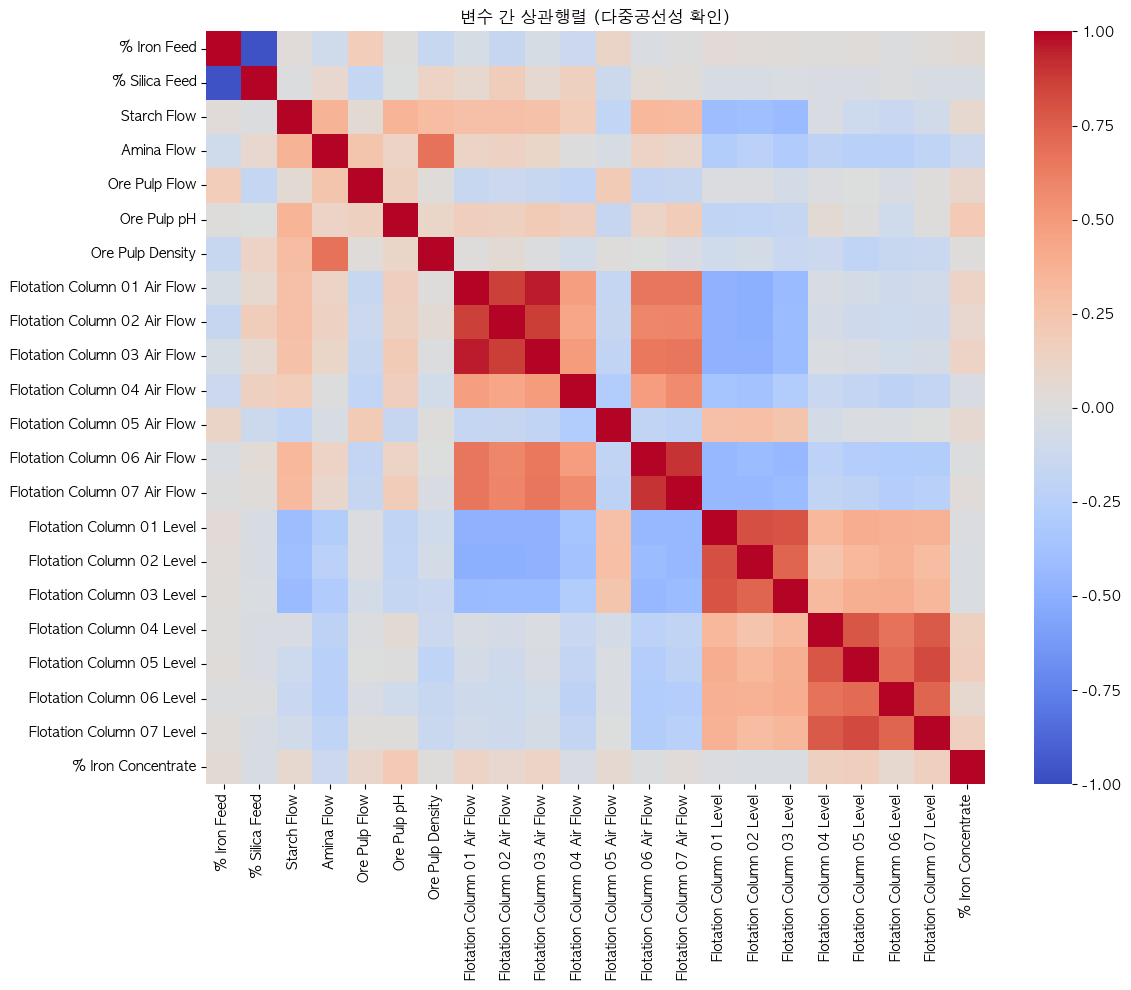

In [16]:
target = "% Silica Concentrate"
num_cols = df_reg.select_dtypes(include="number").columns.drop(target, errors="ignore")

plt.figure(figsize=(12, 10))
sns.heatmap(df_reg[num_cols].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("변수 간 상관행렬 (다중공선성 확인)")
plt.tight_layout()
plt.show()

---
## A-2) 데이터 전처리

### A-2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 모델링 전에 입력변수들을 점검해 보기로 했습니다. AI와 함께 각 변수의 의미를 확인하고, date와 같이 사용 여부를 고민해야 하는 변수나 데이터 누수를 유발할 수 있는 변수가 없는지 검토하고 제거해보세요.

In [17]:
target = "% Silica Concentrate"

# 제거할 변수
drop_cols = ["date", "% Iron Concentrate"]

# date는 train/test 분할용으로 따로 보관
df_reg["date"] = pd.to_datetime(df_reg["date"])

Y_reg = df_reg[target]
X_reg = df_reg.drop(columns=drop_cols + [target])

print("제거:", drop_cols)
print("입력 변수 수:", X_reg.shape[1])
print("입력 변수:", X_reg.columns.tolist())

제거: ['date', '% Iron Concentrate']
입력 변수 수: 21
입력 변수: ['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level']


### A-2-2) 입출력 변수 분할 및 데이터 분할

**[과제]** 써니는 `% Silica Concentrate`를 예측하기 위해 입력변수와 타겟 변수를 분리하고자 합니다. 또한 데이터가 시간에 따라 수집되었다는 점을 고려하여 어떤 방식으로 학습 데이터와 테스트 데이터를 나누는 것이 적절할지 AI와 상의한 후, 데이터를 분할해 보세요.

In [18]:
target = "% Silica Concentrate"
drop_cols = ["date", "% Iron Concentrate"]

df = df_reg.sort_values("date").reset_index(drop=True)

Y = df[target]
X = df.drop(columns=drop_cols + [target])

split_idx = int(len(df) * 0.7)  # 70:30

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
Y_train, Y_test = Y.iloc[:split_idx], Y.iloc[split_idx:]

print("train:", X_train.shape, "test:", X_test.shape)
print("train 기간:", df["date"].iloc[0], "~", df["date"].iloc[split_idx-1])
print("test  기간:", df["date"].iloc[split_idx], "~", df["date"].iloc[-1])

train: (2763, 21) test: (1185, 21)
train 기간: 2017-03-29 12:00:00 ~ 2017-07-22 14:00:00
test  기간: 2017-07-22 15:00:00 ~ 2017-09-09 23:00:00


### A-2-3) 변수 스케일링 및 인코딩

**[과제]** 써니는 변수마다 값의 범위와 단위가 다를 경우 스케일링이 필요하고 범주형 변수의 경우 숫자로 바꿔주는 인코딩이 필요할 수 있다는 것을 배웠습니다. AI와 함께 적절한 스케일링 및 인코딩 기법을 선택하여 적용해 보세요.

In [19]:
from sklearn.preprocessing import StandardScaler

# 인코딩: 회귀 데이터는 수치형만 → 생략

# 스케일링 (선형 계열 모델용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 선형/Ridge/Lasso → X_train_scaled 사용
# 의사결정나무 → X_train 원본 사용

---
## A-3) 모델링

### A-3-1) 다중선형회귀

**[과제]** 써니는 다중선형회귀 모델을 학습시키고, 회귀 계수를 통해 어떤 공정 변수가 실리카 비율에 큰 영향을 주는지 확인하려고 합니다. 모델을 학습하고 회귀 계수를 변수명과 함께 정리해 보세요.

In [21]:
from sklearn.linear_model import LinearRegression

# 선형회귀는 스케일링된 데이터 사용 (앞에서 scaler 적용했다면)
LR = LinearRegression()
LR.fit(X_train_scaled, Y_train)

# 회귀 계수 정리
coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": LR.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("절편(intercept):", LR.intercept_)
print("\n=== 회귀 계수 ===")
display(coef_df)

Y_pred = LR.predict(X_test_scaled)

print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))
print("R2  :", r2_score(Y_test, Y_pred))

절편(intercept): 2.307117263843648

=== 회귀 계수 ===


,Variable,Coefficient
1,% Silica Feed,0.345704
0,% Iron Feed,0.304515
3,Amina Flow,0.298111
10,Flotation Column 04 Air Flow,0.271379
9,Flotation Column 03 Air Flow,-0.269015
7,Flotation Column 01 Air Flow,-0.250680
12,Flotation Column 06 Air Flow,-0.245870
13,Flotation Column 07 Air Flow,0.186287
18,Flotation Column 05 Level,-0.156506
6,Ore Pulp Density,-0.145182


RMSE: 1.203477454484693
R2  : -0.12549365003857305


### A-3-2) Ridge/Lasso 회귀

**[과제]** 써니는 A-1에서 확인한 다중공선성 문제가 정규화(Regularization) 기법을 통해 완화될 수 있는지 확인해보려고 합니다. Ridge 회귀와 Lasso 회귀 모델을 학습하고 각 모델의 예측 성능과 계수 변화를 함께 분석하여, 해당 데이터에 가장 적절한 모델을 선택하세요.

In [22]:
from sklearn.linear_model import Ridge, Lasso

alpha = 1.0  # 규제 강도 (작을수록 약함, 클수록 강함)

LR  = LinearRegression().fit(X_train_scaled, Y_train)
Ridge_model = Ridge(alpha=alpha).fit(X_train_scaled, Y_train)
Lasso_model = Lasso(alpha=alpha, max_iter=10000).fit(X_train_scaled, Y_train)

models = {"Linear": LR, "Ridge": Ridge_model, "Lasso": Lasso_model}

# 1) 예측 성능 비교
results = []
for name, model in models.items():
    pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(Y_test, pred)),
        "MAE": mean_absolute_error(Y_test, pred),
        "R2": r2_score(Y_test, pred),
    })

result_df = pd.DataFrame(results).sort_values("RMSE")
print("=== 예측 성능 ===")
display(result_df)

# 2) 회귀 계수 비교
coef_compare = pd.DataFrame({
    "Variable": X_train.columns,
    "Linear": LR.coef_,
    "Ridge": Ridge_model.coef_,
    "Lasso": Lasso_model.coef_,
})
coef_compare["Lasso_zero"] = coef_compare["Lasso"] == 0

print("\n=== 회귀 계수 비교 ===")
display(coef_compare.sort_values("Ridge", key=abs, ascending=False))

print(f"\nLasso가 0으로 만든 변수 수: {coef_compare['Lasso_zero'].sum()}개")

=== 예측 성능 ===


,Model,RMSE,MAE,R2
2,Lasso,1.135522,0.900161,-0.001978
1,Ridge,1.201807,0.903589,-0.122372
0,Linear,1.203477,0.904676,-0.125494



=== 회귀 계수 비교 ===


,Variable,Linear,Ridge,Lasso,Lasso_zero
1,% Silica Feed,0.345704,0.339428,0.0,True
0,% Iron Feed,0.304515,0.297906,-0.0,True
3,Amina Flow,0.298111,0.297666,0.0,True
10,Flotation Column 04 Air Flow,0.271379,0.270930,0.0,True
9,Flotation Column 03 Air Flow,-0.269015,-0.266994,-0.0,True
7,Flotation Column 01 Air Flow,-0.250680,-0.251185,-0.0,True
12,Flotation Column 06 Air Flow,-0.245870,-0.243132,-0.0,True
13,Flotation Column 07 Air Flow,0.186287,0.184226,-0.0,True
18,Flotation Column 05 Level,-0.156506,-0.156619,-0.0,True
6,Ore Pulp Density,-0.145182,-0.145014,0.0,True



Lasso가 0으로 만든 변수 수: 21개


### A-3-3) 의사결정나무 회귀

**[과제]** 써니는 공정 변수와 % Silica Concentrate 사이에 선형 회귀만으로는 설명하기 어려운 비선형 관계가 존재할 수 있다고 생각했습니다. AI와 함께 회귀 나무 모델을 구축하고 학습된 트리를 시각화하여 주요 분할 기준과 의사결정 과정을 해석해 보세요.

RMSE: 1.0985539703709484
R2  : 0.06220064948719928
                        Variable  Importance
9   Flotation Column 03 Air Flow    0.299514
10  Flotation Column 04 Air Flow    0.124147
1                  % Silica Feed    0.098506
3                     Amina Flow    0.094026
20     Flotation Column 07 Level    0.067695
7   Flotation Column 01 Air Flow    0.055877
18     Flotation Column 05 Level    0.055529
2                    Starch Flow    0.050867
6               Ore Pulp Density    0.039910
11  Flotation Column 05 Air Flow    0.031296


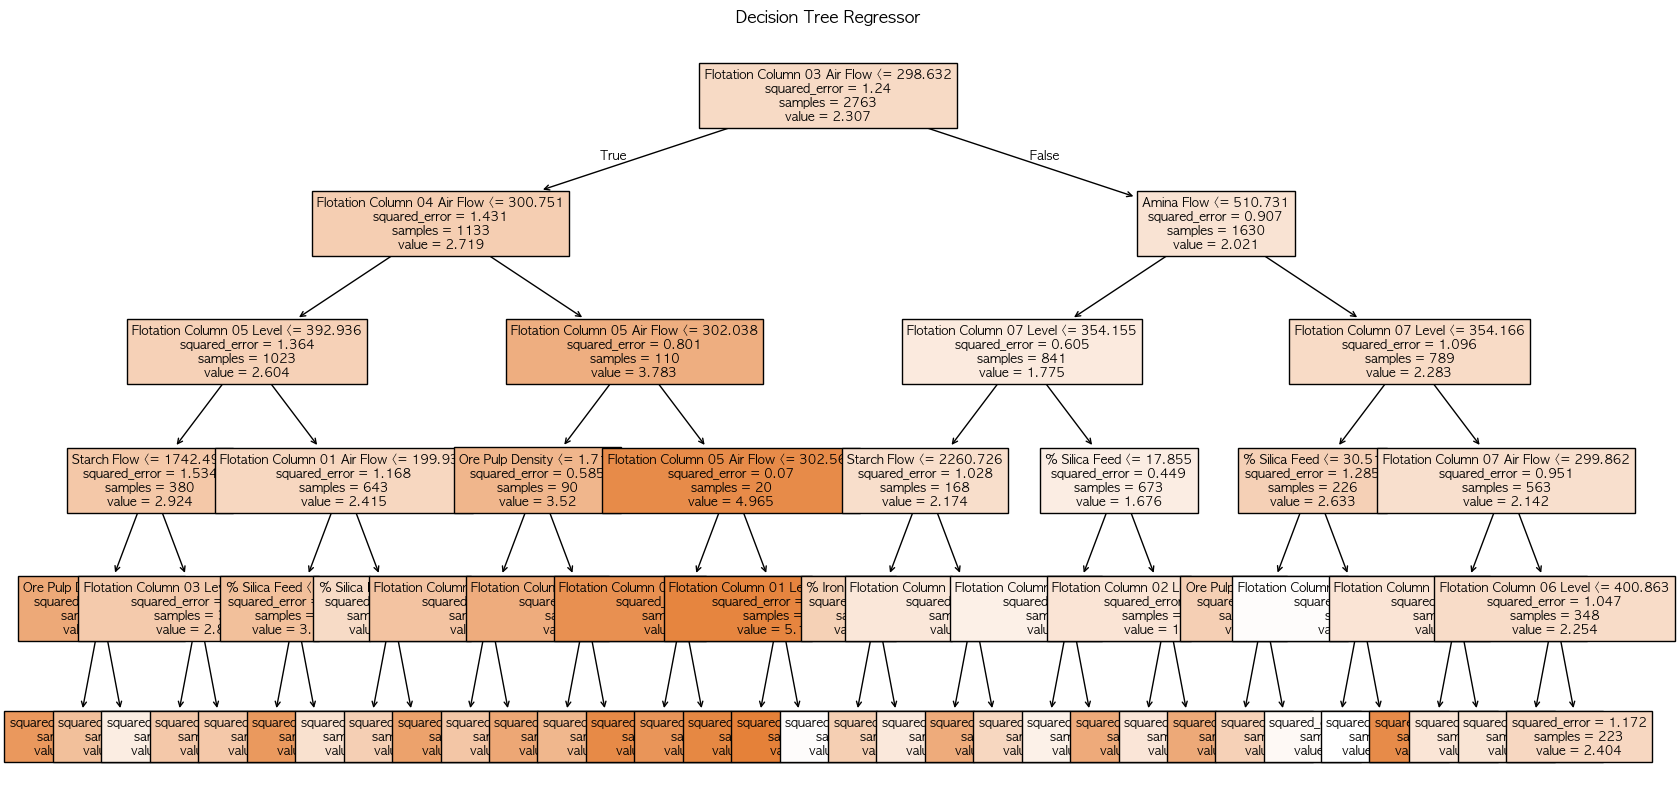

|--- Flotation Column 03 Air Flow <= 298.63
|   |--- Flotation Column 04 Air Flow <= 300.75
|   |   |--- Flotation Column 05 Level <= 392.94
|   |   |   |--- Starch Flow <= 1742.49
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Starch Flow >  1742.49
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Flotation Column 05 Level >  392.94
|   |   |   |--- Flotation Column 01 Air Flow <= 199.93
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Flotation Column 01 Air Flow >  199.93
|   |   |   |   |--- truncated branch of depth 2
|   |--- Flotation Column 04 Air Flow >  300.75
|   |   |--- Flotation Column 05 Air Flow <= 302.04
|   |   |   |--- Ore Pulp Density <= 1.72
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Ore Pulp Density >  1.72
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Flotation Column 05 Air Flow >  302.04
|   |   |   |--- Flotation Column 05 Air Flow <= 302.56
|   |   |   |   |--- truncated b

In [24]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

# 의사결정나무는 스케일링 불필요
DT_reg = DecisionTreeRegressor(max_depth=5, random_state=0)
DT_reg.fit(X_train, Y_train)

# 성능
Y_pred = DT_reg.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))
print("R2  :", r2_score(Y_test, Y_pred))

# 변수 중요도
imp = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": DT_reg.feature_importances_
}).sort_values("Importance", ascending=False)
print(imp.head(10))

# 트리 시각화
plt.figure(figsize=(20, 10))
plot_tree(DT_reg, feature_names=X_train.columns, filled=True, fontsize=9)
plt.title("Decision Tree Regressor")
plt.show()

# 텍스트 규칙 (해석용)
print(export_text(DT_reg, feature_names=list(X_train.columns), max_depth=3))

---
## A-4) 모델 결과 분석 및 고도화

**[과제]** 써니는 지금까지 만든 회귀 모델들(다중선형회귀, Ridge, Lasso, 의사결정나무)의 성능(RMSE, R-squared 등)을 표나 그래프로 한눈에 비교하고 싶습니다. AI와 상의해서 종합 비교 자료를 만들어 보세요.

In [25]:
models = {
    "Linear Regression": (LR, X_test_scaled),
    "Ridge": (Ridge_model, X_test_scaled),
    "Lasso": (Lasso_model, X_test_scaled),
    "Decision Tree": (DT_reg, X_test),
}

compare = []
for name, (model, X_te) in models.items():
    pred = model.predict(X_te)
    compare.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(Y_test, pred)),
        "MAE": mean_absolute_error(Y_test, pred),
        "R2": r2_score(Y_test, pred),
    })

compare_df = pd.DataFrame(compare).sort_values("RMSE")
print("=== 회귀 모델 성능 비교 ===")
display(compare_df)

=== 회귀 모델 성능 비교 ===


,Model,RMSE,MAE,R2
3,Decision Tree,1.098554,0.828548,0.062201
2,Lasso,1.135522,0.900161,-0.001978
1,Ridge,1.201807,0.903589,-0.122372
0,Linear Regression,1.203477,0.904676,-0.125494


**[과제]** 써니는 선형 계열 모델의 회귀 계수와 의사결정나무의 변수 중요도를 함께 비교해서, 어떤 공정 변수가 모델 종류와 관계없이 일관되게 중요하게 나타나는지 확인하고 싶습니다. AI와 상의해서 비교 시각화를 만들어 보세요.

In [26]:
# 1) 선형 계열: 절댓값 계수 (Ridge 또는 Lasso 추천)
linear_imp = np.abs(Ridge_model.coef_)
linear_imp = linear_imp / linear_imp.max()  # 0~1 정규화

# 2) 의사결정나무: feature_importances_ (이미 0~1)
tree_imp = DT_reg.feature_importances_

# 3) 통합 테이블
imp_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Linear(|coef|)": linear_imp,
    "Tree(importance)": tree_imp,
})
imp_df["Average"] = imp_df[["Linear(|coef|)", "Tree(importance)"]].mean(axis=1)
imp_df = imp_df.sort_values("Average", ascending=False)

print("=== 변수 중요도 비교 (Top 10) ===")
display(imp_df.head(10))

=== 변수 중요도 비교 (Top 10) ===


,Variable,Linear(|coef|),Tree(importance),Average
1,% Silica Feed,1.000000,0.098506,0.549253
9,Flotation Column 03 Air Flow,0.786601,0.299514,0.543058
3,Amina Flow,0.876963,0.094026,0.485495
10,Flotation Column 04 Air Flow,0.798198,0.124147,0.461173
0,% Iron Feed,0.877671,0.005970,0.441821
7,Flotation Column 01 Air Flow,0.740027,0.055877,0.397952
12,Flotation Column 06 Air Flow,0.716299,0.000068,0.358184
13,Flotation Column 07 Air Flow,0.542754,0.010146,0.276450
18,Flotation Column 05 Level,0.461422,0.055529,0.258475
6,Ore Pulp Density,0.427231,0.039910,0.233570


In [27]:
def norm_abs(x):
    x = np.abs(x)
    return x / x.max() if x.max() > 0 else x

imp_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Linear": norm_abs(LR.coef_),
    "Ridge": norm_abs(Ridge_model.coef_),
    "Lasso": norm_abs(Lasso_model.coef_),
    "Tree": DT_reg.feature_importances_,
})

imp_df["Average"] = imp_df[["Linear", "Ridge", "Lasso", "Tree"]].mean(axis=1)
imp_df = imp_df.sort_values("Average", ascending=False)
display(imp_df.head(10))

,Variable,Linear,Ridge,Lasso,Tree,Average
1,% Silica Feed,1.000000,1.000000,0.0,0.098506,0.524627
9,Flotation Column 03 Air Flow,0.778167,0.786601,0.0,0.299514,0.466071
3,Amina Flow,0.862331,0.876963,0.0,0.094026,0.458330
0,% Iron Feed,0.880855,0.877671,0.0,0.005970,0.441124
10,Flotation Column 04 Air Flow,0.785003,0.798198,0.0,0.124147,0.426837
7,Flotation Column 01 Air Flow,0.725128,0.740027,0.0,0.055877,0.380258
12,Flotation Column 06 Air Flow,0.711214,0.716299,0.0,0.000068,0.356895
13,Flotation Column 07 Air Flow,0.538862,0.542754,0.0,0.010146,0.272940
18,Flotation Column 05 Level,0.452716,0.461422,0.0,0.055529,0.242417
6,Ore Pulp Density,0.419961,0.427231,0.0,0.039910,0.221775


**[과제]** 써니는 여러 회귀 모델 중 가장 우수한 모델을 발견했지만, 아직 성능을 더 개선할 여지가 있다고 생각했습니다. AI와 함께 어떤 하이퍼파라미터를 조정해야 할지 논의하고, 적절한 탐색 범위를 설정하여 모델 성능을 최대한 높여보세요.

In [28]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [29]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

RF = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0, n_jobs=-1)
XGB = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                   random_state=0, n_jobs=-1)

RF.fit(X_train, Y_train)
XGB.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, random_state=0, ...)

In [30]:
models = {
    "Linear Regression": (LR, X_test_scaled),
    "Ridge": (Ridge_model, X_test_scaled),
    "Lasso": (Lasso_model, X_test_scaled),
    "Decision Tree": (DT_reg, X_test),
    "Random Forest": (RF, X_test),
    "XGBoost": (XGB, X_test),
}

compare = []
for name, (model, X_te) in models.items():
    pred = model.predict(X_te)
    compare.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(Y_test, pred)),
        "MAE": mean_absolute_error(Y_test, pred),
        "R2": r2_score(Y_test, pred),
    })

compare_df = pd.DataFrame(compare).sort_values("RMSE")
display(compare_df)

,Model,RMSE,MAE,R2
4,Random Forest,1.072971,0.849715,0.105370
3,Decision Tree,1.098554,0.828548,0.062201
5,XGBoost,1.110179,0.880847,0.042248
2,Lasso,1.135522,0.900161,-0.001978
1,Ridge,1.201807,0.903589,-0.122372
0,Linear Regression,1.203477,0.904676,-0.125494


In [31]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Random Forest
rf_param = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 5, 10],
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=0, n_jobs=-1),
    rf_param, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1
)
rf_search.fit(X_train, Y_train)
RF_best = rf_search.best_estimator_

# XGBoost
xgb_param = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_search = GridSearchCV(
    XGBRegressor(random_state=0, n_jobs=-1),
    xgb_param, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1
)
xgb_search.fit(X_train, Y_train)
XGB_best = xgb_search.best_estimator_

print("RF best :", rf_search.best_params_, "CV RMSE:", -rf_search.best_score_)
print("XGB best:", xgb_search.best_params_, "CV RMSE:", -xgb_search.best_score_)

RF best : {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100} CV RMSE: 1.1051848318496904
XGB best: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0} CV RMSE: 1.096464986122222


In [32]:
def evaluate(name, model, X_te):
    pred = model.predict(X_te)
    return {
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(Y_test, pred)),
        "MAE": mean_absolute_error(Y_test, pred),
        "R2": r2_score(Y_test, pred),
    }

tuned_compare = pd.DataFrame([
    evaluate("RF (before)", RF, X_test),
    evaluate("RF (tuned)", RF_best, X_test),
    evaluate("XGBoost (before)", XGB, X_test),
    evaluate("XGBoost (tuned)", XGB_best, X_test),
]).sort_values("RMSE")

display(tuned_compare)

,Model,RMSE,MAE,R2
1,RF (tuned),1.065137,0.818992,0.118386
0,RF (before),1.072971,0.849715,0.105370
3,XGBoost (tuned),1.080146,0.830303,0.093366
2,XGBoost (before),1.110179,0.880847,0.042248


In [33]:
final_models = {
    "Linear": (LR, X_test_scaled),
    "Ridge": (Ridge_model, X_test_scaled),
    "Lasso": (Lasso_model, X_test_scaled),
    "Decision Tree": (DT_reg, X_test),
    "RF (tuned)": (RF_best, X_test),
    "XGBoost (tuned)": (XGB_best, X_test),
}

final_df = pd.DataFrame([
    evaluate(name, model, X_te) for name, (model, X_te) in final_models.items()
]).sort_values("RMSE")

display(final_df)

,Model,RMSE,MAE,R2
4,RF (tuned),1.065137,0.818992,0.118386
5,XGBoost (tuned),1.080146,0.830303,0.093366
3,Decision Tree,1.098554,0.828548,0.062201
2,Lasso,1.135522,0.900161,-0.001978
1,Ridge,1.201807,0.903589,-0.122372
0,Linear,1.203477,0.904676,-0.125494


---
# Part B. 분류 태스크 — Steel Plates Faults

## B-0) 데이터 불러오기

**[과제]** 써니는 `dataset/day2_miniproject_cls.csv` 파일을 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

---
## B-1) 데이터 탐색 (EDA)

**[과제]** 써니는 타겟 변수의 분포가 어떻게 구성되어 있는지 궁금해졌습니다. AI와 함께 적절한 시각화 기법을 선택하여 타겟 변수의 빈도와 비율을 분석하고, 분석 결과를 바탕으로 향후 모델링 과정에서 고려해야 할 사항이 무엇인지 생각해 보세요.

---
## B-2) 데이터 전처리

### B-2-1) 타겟 변수 정의

**[과제]** 써니는 K_Scratch를 분류 타겟(0/1)으로 사용하기로 했습니다. 이때 나머지 결함 유형 컬럼(Pastry, Z_Scratch, Stains, Dirtiness, Bumps, Other_Faults)이 타겟과 어떤 관계를 가지는지 궁금해졌습니다. AI와 함께 각 변수의 의미와 타겟과의 관계를 분석하고, 모델링 과정에서 해당 변수들을 사용하는 것이 적절한지 판단한 뒤 필요한 전처리를 수행해 보세요.

### B-2-2) 결측치 확인 및 데이터 분할

**[과제]** 써니는 결측치를 확인한 후 모델링을 위한 데이터를 준비하고자 합니다. AI와 함께 변수별 특성을 고려하여 적절한 결측치 처리 방법을 적용하고, 분류 모델 학습에 적합한 방식으로 학습 데이터와 테스트 데이터를 분할해 보세요.

### B-2-3) 변수 스케일링

**[과제]** 써니는 데이터셋에 수치형 변수와 범주형 변수가 함께 존재한다는 점을 확인했습니다. AI와 함께 각 변수의 특성과 분포를 살펴보고, 스케일링이 필요한 변수를 판단한 뒤 적절한 스케일링 기법을 선택하여 적용해 보세요.

---
## B-3) 모델링

### B-3-1) 로지스틱 회귀

**[과제]** 써니는 로지스틱 회귀 모델을 학습시키고, 회귀 계수를 통해 어떤 변수가 K_Scatch 여부에 큰 영향을 주는지 확인하려고 합니다. 모델을 학습하고 회귀 계수의 절대값 기준으로 변수 영향력을 정리해 보세요.

### B-3-2) 의사결정나무 분류

**[과제]** 써니는 의사결정나무를 활용해 K_Scratch가 어떤 변수와 기준값에 의해 분류되는지 직관적으로 이해하고자 합니다. AI와 함께 분류 나무 모델을 구축하고 학습된 트리를 시각화하여 주요 분할 기준과 의사결정 과정을 해석해 보세요.

---
## B-4) 테스트 데이터 예측

**[과제]** 써니는 로지스틱 회귀와 의사결정나무 분류 모델로 테스트 데이터에 대한 예측을 수행하고, Accuracy·Precision·Recall·F1-score와 혼동행렬을 함께 비교하려고 합니다. AI와 상의해서 두 모델의 예측과 성능 지표를 한 번에 뽑을 수 있도록 코드를 작성해 보세요.

---
## B-5) 모델 고도화

**[과제]** 써니는 분류 모델링 결과를 살펴보며 클래스 불균형이 모델 성능에 영향을 줄 수 있다고 생각했습니다. AI와 함께 이를 해결할 수 있는 로지스틱 회귀와 분류 나무 각각에 적합한 하이퍼파라미터와 튜닝 방법을 탐색하고, 최적의 파라미터를 찾아 모델을 다시 학습해 보세요. 이후 성능이 얼마나 개선되었는지 비교해 보세요.